In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
#import numpy as np
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=250):
        """
        Args:
            csv_file (str): Path to the CSV file with protein sequences and modification labels.
            sequence_length (int): Maximum sequence length (padding shorter sequences).
        """
        # Load the CSV data
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)




    def random_shift_sequence(self,sequence, label): #does nothing for now
        """Randomly shifts a sequence and adjusts the label accordingly."""
        shift = np.random.randint(-3, 4)  # Shift left or right by up to 3 positions
        sequence = np.roll(sequence, shift, axis=0)  # Shift sequence
        label = np.roll(label, shift, axis=0)  # Shift labels accordingly
        return sequence, label

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1]
        labels = self.data.iloc[idx, 2]
    
        sequence = sequence.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = labels.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
    
        amino_acid_dict = {
            'A': [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R': [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N': [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D': [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C': [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E': [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q': [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G': [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H': [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I': [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L': [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K': [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F': [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }
    
        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]
    
        sequence_tensor = torch.tensor(sequence_indices).float()  # shape: (seq_len, features)
        labels_tensor = torch.tensor(labels).float()             # shape: (seq_len,)
    
        return sequence_tensor, labels_tensor


# Load the data into a DataLoader
dataset = ProteinDataset(csv_file="code_test_data.csv", sequence_length=33)  # Adjust sequence length based on your data
train_loader = DataLoader(dataset, batch_size=100, shuffle=True)
data_pred = ProteinDataset(csv_file="code_predict.csv", sequence_length=33)
test_loader = DataLoader(data_pred, batch_size=100, shuffle=True)
# Example: Inspecting the loaded data
for batch_idx, (sequences, labels) in enumerate(train_loader):
    print(f"Batch {batch_idx+1}:")
    print("Sequences:", sequences)
    print("Labels:", labels)


Batch 1:
Sequences: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
  

In [2]:
# cleaned_phospho_training.py

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchmetrics
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 43          # sequence window length
FEATURES = 20         # one-hot/embedding depth
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.30
CNN_FILTERS = 32
LSTM_HIDDEN = 64
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.5


# -------------------------------------------------------
# ✅ Protein Dataset
# -------------------------------------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length
        self.amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        sequence_indices = [self.amino_acid_dict[aa] for aa in sequence]
        labels = [int(l) for l in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()   # (seq_len, features)
        labels_tensor = torch.tensor(labels).float()               # (seq_len,)

        return sequence_tensor, labels_tensor


# -------------------------------------------------------
# ✅ MODEL (CNN → BiLSTM → FC)
# -------------------------------------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)

        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            fc_in = lstm_hidden * 2
        else:
            fc_in = cnn_filters
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        x = x.transpose(1, 2)                      # (batch, features, seq_len)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1, 2)                      # (batch, seq_len, channels)
        x = self.dropout(x)
        if self.use_lstm:
            x, _ = self.lstm(x)
        logits = self.fc(x).squeeze(-1)            # (batch, seq_len)
        return logits


# -------------------------------------------------------
# ✅ Focal Loss
# -------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        bce = -(targets*torch.log(probs) + (1-targets)*torch.log(1-probs))
        pt = torch.where(targets==1, probs, 1-probs)
        loss = self.alpha*(1-pt)**self.gamma*bce
        return loss.mean() if self.reduction=="mean" else loss.sum()


# -------------------------------------------------------
# Instantiate model, loss, optimizer, metrics
# -------------------------------------------------------
model = PhosphoModel().to(DEVICE)
criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

f1_metric = torchmetrics.classification.BinaryF1Score(threshold=THRESH)
precision_metric = torchmetrics.classification.BinaryPrecision(threshold=THRESH)
recall_metric = torchmetrics.classification.BinaryRecall(threshold=THRESH)
auroc_metric = torchmetrics.classification.BinaryAUROC()
acc_metric = torchmetrics.classification.BinaryAccuracy(threshold=THRESH)


# -------------------------------------------------------
# Training / Evaluation
# -------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    f1_metric.reset(); precision_metric.reset()
    recall_metric.reset(); auroc_metric.reset(); acc_metric.reset()
    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        logits = model(inputs)
        running_loss += criterion(logits, labels).item()
        probs = torch.sigmoid(logits).view(-1).cpu()
        labels = labels.view(-1).cpu()
        preds_bin = (probs>THRESH).int()
        f1_metric.update(preds_bin, labels)
        precision_metric.update(preds_bin, labels)
        recall_metric.update(preds_bin, labels)
        auroc_metric.update(probs, labels)
        acc_metric.update(preds_bin, labels)
    return running_loss/len(loader), {
        "val_f1": f1_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
        "auroc": auroc_metric.compute().item(),
        "accuracy": acc_metric.compute().item()
    }


# -------------------------------------------------------
# REPLACE THESE WITH YOUR DATALOADERS
# -------------------------------------------------------



# -------------------------------------------------------
# Training loop with checkpoint
# -------------------------------------------------------
best_f1 = 0.0
for epoch in range(1, EPOCHS+1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, metrics = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | F1: {metrics['val_f1']:.4f}")
    if metrics["val_f1"] > best_f1:
        best_f1 = metrics["val_f1"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model (F1={best_f1:.4f}) → {CHECKPOINT_PATH}")

print("\nTraining complete.")
print(f"Best model F1: {best_f1:.4f}")


NameError: name 'val_loader' is not defined

In [4]:
# phospho_training_full.py

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchmetrics
import pandas as pd

# --------------------------
# DEVICE & HYPERPARAMETERS
# --------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33          # sequence window length
FEATURES = 20         # one-hot depth for amino acids
BATCH_SIZE = 100
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.30
CNN_FILTERS = 32
LSTM_HIDDEN = 64
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.5

# --------------------------
# DATASET
# --------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1]
        labels = self.data.iloc[idx, 2]

        # Clean strings
        sequence = sequence.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = labels.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')

        # One-hot encoding dictionary
        amino_acid_dict = {
            'A': [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R': [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N': [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D': [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C': [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E': [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q': [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G': [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H': [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I': [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L': [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K': [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F': [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()  # (seq_len, features)
        labels_tensor = torch.tensor(labels).float()             # (seq_len,)

        return sequence_tensor, labels_tensor

# --------------------------
# SPLIT DATASET
# --------------------------
full_dataset = ProteinDataset(csv_file="code_test_data.csv", sequence_length=SEQ_LEN)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --------------------------
# MODEL
# --------------------------
class PhosphoModel(nn.Module):
    def __init__(self,
                 seq_len=SEQ_LEN,
                 input_dim=FEATURES,
                 cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN,
                 use_lstm=USE_LSTM,
                 dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm

        self.conv1 = nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)

        if use_lstm:
            self.lstm = nn.LSTM(
                input_size=cnn_filters,
                hidden_size=lstm_hidden,
                bidirectional=True,
                batch_first=True
            )
            fc_in = lstm_hidden * 2
        else:
            fc_in = cnn_filters

        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        # x: [batch, seq_len, features] → [batch, features, seq_len] for Conv1d
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = x.transpose(1, 2)  # back to [batch, seq_len, channels]
        x = self.dropout(x)

        if self.use_lstm:
            x, _ = self.lstm(x)

        logits = self.fc(x).squeeze(-1)  # [batch, seq_len]
        return logits

# --------------------------
# LOSS, OPTIMIZER, METRICS
# --------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        bce = -(targets * torch.log(probs) + (1 - targets) * torch.log(1 - probs))
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean() if self.reduction == "mean" else loss.sum()

model = PhosphoModel().to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Torchmetrics
f1_metric = torchmetrics.classification.BinaryF1Score(threshold=THRESH)
precision_metric = torchmetrics.classification.BinaryPrecision(threshold=THRESH)
recall_metric = torchmetrics.classification.BinaryRecall(threshold=THRESH)
auroc_metric = torchmetrics.classification.BinaryAUROC()
acc_metric = torchmetrics.classification.BinaryAccuracy(threshold=THRESH)

# --------------------------
# TRAIN/EVAL FUNCTIONS
# --------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    f1_metric.reset(); precision_metric.reset()
    recall_metric.reset(); auroc_metric.reset(); acc_metric.reset()

    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        logits = model(inputs)
        running_loss += criterion(logits, labels).item()

        probs = torch.sigmoid(logits).view(-1).cpu()
        labels = labels.view(-1).cpu()
        preds_bin = (probs > THRESH).int()

        f1_metric.update(preds_bin, labels)
        precision_metric.update(preds_bin, labels)
        recall_metric.update(preds_bin, labels)
        auroc_metric.update(probs, labels)
        acc_metric.update(preds_bin, labels)

    return running_loss / len(loader), {
        "val_f1": f1_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
        "auroc": auroc_metric.compute().item(),
        "accuracy": acc_metric.compute().item()
    }

# --------------------------
# TRAINING LOOP
# --------------------------
best_f1 = 0.0
for epoch in range(1, EPOCHS+1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, metrics = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | F1: {metrics['val_f1']:.4f}")

    if metrics["val_f1"] > best_f1:
        best_f1 = metrics["val_f1"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model (F1={best_f1:.4f}) → {CHECKPOINT_PATH}")

print("\nTraining complete.")
print(f"Best model F1: {best_f1:.4f}")


Epoch 1/200 | Train Loss: 0.0260 | Val Loss: 0.0192 | F1: 0.0003
✅ Saved best model (F1=0.0003) → best_phospho_model.pth
Epoch 2/200 | Train Loss: 0.0156 | Val Loss: 0.0119 | F1: 0.5891
✅ Saved best model (F1=0.5891) → best_phospho_model.pth
Epoch 3/200 | Train Loss: 0.0111 | Val Loss: 0.0101 | F1: 0.6993
✅ Saved best model (F1=0.6993) → best_phospho_model.pth
Epoch 4/200 | Train Loss: 0.0102 | Val Loss: 0.0098 | F1: 0.7080
✅ Saved best model (F1=0.7080) → best_phospho_model.pth
Epoch 5/200 | Train Loss: 0.0099 | Val Loss: 0.0095 | F1: 0.7176
✅ Saved best model (F1=0.7176) → best_phospho_model.pth
Epoch 6/200 | Train Loss: 0.0096 | Val Loss: 0.0094 | F1: 0.7295
✅ Saved best model (F1=0.7295) → best_phospho_model.pth
Epoch 7/200 | Train Loss: 0.0094 | Val Loss: 0.0092 | F1: 0.7385
✅ Saved best model (F1=0.7385) → best_phospho_model.pth
Epoch 8/200 | Train Loss: 0.0092 | Val Loss: 0.0091 | F1: 0.7444
✅ Saved best model (F1=0.7444) → best_phospho_model.pth
Epoch 9/200 | Train Loss: 0.0090

# same model above but with everything printed


Epoch 1/200 | Train Loss: 0.0235 | Val Loss: 0.0164 | F1: 0.0416 | Precision: 0.6043 | Recall: 0.0215 | AUROC: 0.9255 | Acc: 0.8735
✅ Saved best model with F1: 0.0416
Epoch 2/200 | Train Loss: 0.0130 | Val Loss: 0.0102 | F1: 0.6892 | Precision: 0.6801 | Recall: 0.6986 | AUROC: 0.9601 | Acc: 0.9197
✅ Saved best model with F1: 0.6892
Epoch 3/200 | Train Loss: 0.0103 | Val Loss: 0.0096 | F1: 0.7155 | Precision: 0.6893 | Recall: 0.7437 | AUROC: 0.9651 | Acc: 0.9246
✅ Saved best model with F1: 0.7155
Epoch 4/200 | Train Loss: 0.0097 | Val Loss: 0.0093 | F1: 0.7195 | Precision: 0.7093 | Recall: 0.7301 | AUROC: 0.9679 | Acc: 0.9275
✅ Saved best model with F1: 0.7195
Epoch 5/200 | Train Loss: 0.0094 | Val Loss: 0.0091 | F1: 0.7360 | Precision: 0.7128 | Recall: 0.7606 | AUROC: 0.9701 | Acc: 0.9305
✅ Saved best model with F1: 0.7360
Epoch 6/200 | Train Loss: 0.0091 | Val Loss: 0.0089 | F1: 0.7364 | Precision: 0.7341 | Recall: 0.7388 | AUROC: 0.9718 | Acc: 0.9326
✅ Saved best model with F1: 0.736

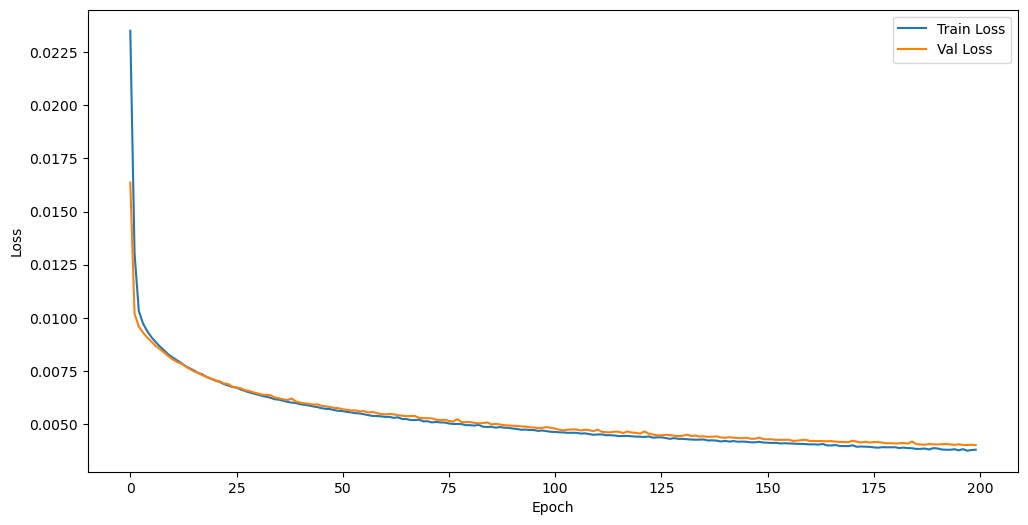

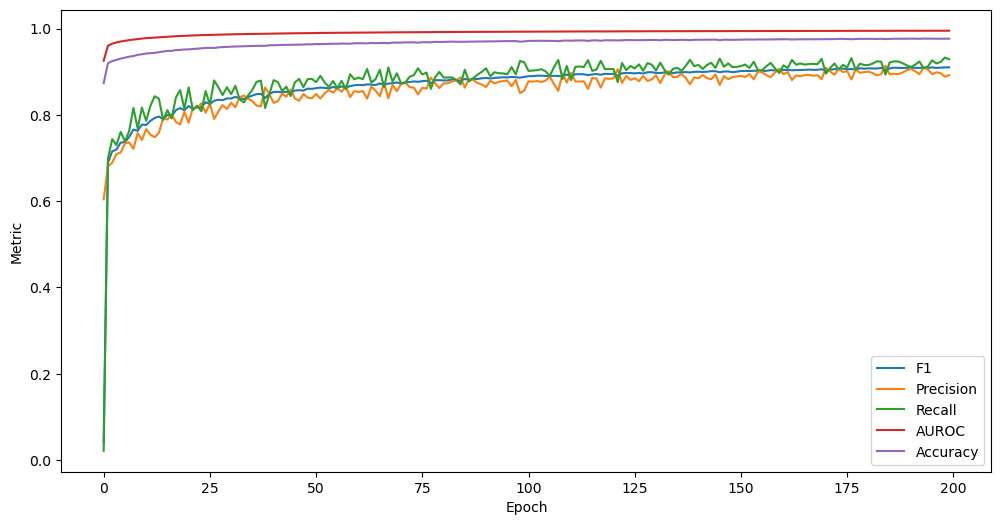

In [7]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchmetrics
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33          # sequence window length
FEATURES = 20         # one-hot depth
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.3
CNN_FILTERS = 32
LSTM_HIDDEN = 64
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.5

# ----------------------------
# Dataset (your loader)
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()  # shape: (seq_len, features)
        labels_tensor = torch.tensor(labels).float()             # shape: (seq_len,)
        return sequence_tensor, labels_tensor

# ----------------------------
# Model
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        x = x.transpose(1,2)             # (batch, features, seq_len)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)             # (batch, seq_len, channels)
        x = self.dropout(x)
        if self.use_lstm:
            x,_ = self.lstm(x)
        logits = self.fc(x).squeeze(-1)
        return logits

# ----------------------------
# Focal Loss
# ----------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        bce = -(targets*torch.log(probs) + (1-targets)*torch.log(1-probs))
        pt = torch.where(targets==1, probs, 1-probs)
        loss = self.alpha*(1-pt)**self.gamma * bce
        return loss.mean() if self.reduction=="mean" else loss.sum()

# ----------------------------
# Instantiate model, optimizer, criterion, metrics
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

f1_metric = torchmetrics.classification.BinaryF1Score(threshold=THRESH)
precision_metric = torchmetrics.classification.BinaryPrecision(threshold=THRESH)
recall_metric = torchmetrics.classification.BinaryRecall(threshold=THRESH)
auroc_metric = torchmetrics.classification.BinaryAUROC()
acc_metric = torchmetrics.classification.BinaryAccuracy(threshold=THRESH)

# ----------------------------
# Loaders
# ----------------------------
dataset = ProteinDataset("code_test_data.csv")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training & Validation Loop
# ----------------------------
best_f1 = 0
history = {"train_loss":[],"val_loss":[],"val_f1":[],"precision":[],"recall":[],"auroc":[],"accuracy":[]}

for epoch in range(1, EPOCHS+1):
    # ---- Training ----
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    history["train_loss"].append(train_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    f1_metric.reset(); precision_metric.reset()
    recall_metric.reset(); auroc_metric.reset(); acc_metric.reset()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
            logits = model(inputs)
            val_loss += criterion(logits, labels).item()

            probs = torch.sigmoid(logits).view(-1).cpu()
            labels_flat = labels.view(-1).cpu()
            preds_bin = (probs>THRESH).int()

            f1_metric.update(preds_bin, labels_flat)
            precision_metric.update(preds_bin, labels_flat)
            recall_metric.update(preds_bin, labels_flat)
            auroc_metric.update(probs, labels_flat)
            acc_metric.update(preds_bin, labels_flat)

    val_loss /= len(val_loader)
    val_f1 = f1_metric.compute().item()
    precision = precision_metric.compute().item()
    recall = recall_metric.compute().item()
    auroc = auroc_metric.compute().item()
    accuracy = acc_metric.compute().item()

    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["auroc"].append(auroc)
    history["accuracy"].append(accuracy)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
          f"| F1: {val_f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} "
          f"| AUROC: {auroc:.4f} | Acc: {accuracy:.4f}")

    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["val_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.plot(history["auroc"], label="AUROC")
plt.plot(history["accuracy"], label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.show()
